# Анализ результатов embedding-классификаторов

Ноутбук показывает только ключевые результаты экспериментов: общий рейтинг моделей, сравнение baseline и thresholded-версий, качество по классам и итоговый выбор модели.

## 1. Общее сравнение всех конфигураций

Ниже выведены 10 лучших конфигураций из полного перебора embedding-моделей и классических классификаторов. Сравниваем по `macro_f1`, потому что это multi-label задача с разными классами, и важно качество не только на частых классах.

**Главный вывод:** лучший результат без дополнительного подбора порогов дала связка `bge-m3 + LinearSVC_balanced`: `macro_f1 ≈ 0.813`. В топе также находятся `SGD_hinge_balanced`, `USER-bge-m3 + LinearSVC_balanced` и `USER-bge-m3 + Ridge_balanced`.

In [1]:
import pandas as pd
from IPython.display import display
df = pd.DataFrame([
  {
    "model": "bge-m3 + LinearSVC_balanced",
    "macro_precision": 0.768,
    "macro_recall": 0.877,
    "macro_f1": 0.813,
    "micro_f1": 0.828,
    "weighted_f1": 0.83
  },
  {
    "model": "bge-m3 + SGD_hinge_balanced",
    "macro_precision": 0.761,
    "macro_recall": 0.879,
    "macro_f1": 0.806,
    "micro_f1": 0.827,
    "weighted_f1": 0.831
  },
  {
    "model": "USER-bge-m3 + LinearSVC_balanced",
    "macro_precision": 0.757,
    "macro_recall": 0.863,
    "macro_f1": 0.805,
    "micro_f1": 0.828,
    "weighted_f1": 0.828
  },
  {
    "model": "USER-bge-m3 + Ridge_balanced",
    "macro_precision": 0.734,
    "macro_recall": 0.909,
    "macro_f1": 0.802,
    "micro_f1": 0.817,
    "weighted_f1": 0.821
  },
  {
    "model": "bge-m3 + Ridge_balanced",
    "macro_precision": 0.731,
    "macro_recall": 0.888,
    "macro_f1": 0.795,
    "micro_f1": 0.818,
    "weighted_f1": 0.821
  },
  {
    "model": "ru-en-RoSBERTa + LinearSVC_balanced",
    "macro_precision": 0.741,
    "macro_recall": 0.863,
    "macro_f1": 0.793,
    "micro_f1": 0.799,
    "weighted_f1": 0.801
  },
  {
    "model": "ru-en-RoSBERTa + SGD_logloss_balanced",
    "macro_precision": 0.732,
    "macro_recall": 0.878,
    "macro_f1": 0.787,
    "micro_f1": 0.786,
    "weighted_f1": 0.79
  },
  {
    "model": "USER-bge-m3 + SGD_logloss_balanced",
    "macro_precision": 0.748,
    "macro_recall": 0.858,
    "macro_f1": 0.783,
    "micro_f1": 0.802,
    "weighted_f1": 0.806
  },
  {
    "model": "bge-m3 + SGD_logloss_balanced",
    "macro_precision": 0.773,
    "macro_recall": 0.836,
    "macro_f1": 0.782,
    "micro_f1": 0.796,
    "weighted_f1": 0.802
  },
  {
    "model": "ru-en-RoSBERTa + Ridge_balanced",
    "macro_precision": 0.715,
    "macro_recall": 0.875,
    "macro_f1": 0.781,
    "micro_f1": 0.786,
    "weighted_f1": 0.789
  }
])
df = df.sort_values('macro_f1', ascending=False)
display(df)

,model,macro_precision,macro_recall,macro_f1,micro_f1,weighted_f1
0,bge-m3 + LinearSVC_balanced,0.768,0.877,0.813,0.828,0.830
1,bge-m3 + SGD_hinge_balanced,0.761,0.879,0.806,0.827,0.831
2,USER-bge-m3 + LinearSVC_balanced,0.757,0.863,0.805,0.828,0.828
3,USER-bge-m3 + Ridge_balanced,0.734,0.909,0.802,0.817,0.821
4,bge-m3 + Ridge_balanced,0.731,0.888,0.795,0.818,0.821
5,ru-en-RoSBERTa + LinearSVC_balanced,0.741,0.863,0.793,0.799,0.801
6,ru-en-RoSBERTa + SGD_logloss_balanced,0.732,0.878,0.787,0.786,0.790
7,USER-bge-m3 + SGD_logloss_balanced,0.748,0.858,0.783,0.802,0.806
8,bge-m3 + SGD_logloss_balanced,0.773,0.836,0.782,0.796,0.802
9,ru-en-RoSBERTa + Ridge_balanced,0.715,0.875,0.781,0.786,0.789


## 2. Визуальное сравнение топ-10 моделей

График показывает, что несколько лучших конфигураций идут достаточно близко друг к другу. Разрыв между первым и вторым местом небольшой, поэтому дальше отдельно проверялся подбор порогов для трех лучших кандидатов.

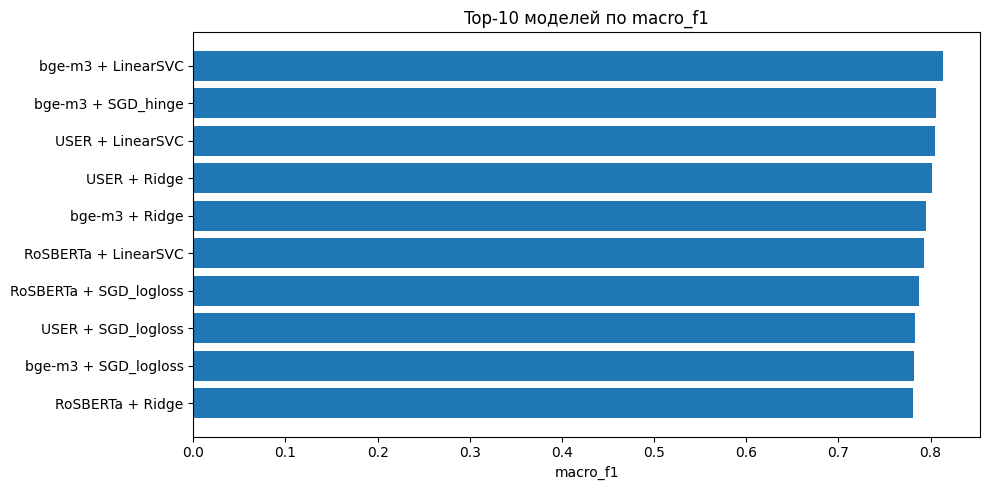

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame([
  {
    "model_short": "bge-m3 + LinearSVC",
    "macro_f1": 0.813
  },
  {
    "model_short": "bge-m3 + SGD_hinge",
    "macro_f1": 0.806
  },
  {
    "model_short": "USER + LinearSVC",
    "macro_f1": 0.805
  },
  {
    "model_short": "USER + Ridge",
    "macro_f1": 0.802
  },
  {
    "model_short": "bge-m3 + Ridge",
    "macro_f1": 0.795
  },
  {
    "model_short": "RoSBERTa + LinearSVC",
    "macro_f1": 0.793
  },
  {
    "model_short": "RoSBERTa + SGD_logloss",
    "macro_f1": 0.787
  },
  {
    "model_short": "USER + SGD_logloss",
    "macro_f1": 0.783
  },
  {
    "model_short": "bge-m3 + SGD_logloss",
    "macro_f1": 0.782
  },
  {
    "model_short": "RoSBERTa + Ridge",
    "macro_f1": 0.781
  }
])
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(df['model_short'], df['macro_f1'])
ax.set_title('Top-10 моделей по macro_f1')
ax.set_xlabel('macro_f1')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 3. Baseline vs thresholded для трех выбранных моделей

После первичного сравнения были выбраны три сильные конфигурации. Для них был проведен подбор индивидуального порога по каждому классу.

**Главный вывод:** лучшая итоговая модель — `bge-m3 + LinearSVC_balanced__thresholded`. Она дала максимальный `macro_f1 ≈ 0.822`. Подбор порогов чаще повышает precision, но снижает recall, поэтому эффект по F1 умеренный.

In [3]:
import pandas as pd
from IPython.display import display
df = pd.DataFrame([
  {
    "model": "bge-m3 + LinearSVC_balanced__thresholded",
    "macro_precision": 0.82,
    "macro_recall": 0.833,
    "macro_f1": 0.822,
    "micro_f1": 0.829,
    "weighted_f1": 0.829,
    "threshold_tuning": "oof_per_class_f1"
  },
  {
    "model": "bge-m3 + LinearSVC_balanced__baseline",
    "macro_precision": 0.768,
    "macro_recall": 0.877,
    "macro_f1": 0.813,
    "micro_f1": 0.828,
    "weighted_f1": 0.83,
    "threshold_tuning": "none"
  },
  {
    "model": "USER-bge-m3 + Ridge_balanced__thresholded",
    "macro_precision": 0.825,
    "macro_recall": 0.815,
    "macro_f1": 0.813,
    "micro_f1": 0.819,
    "weighted_f1": 0.82,
    "threshold_tuning": "oof_per_class_f1"
  },
  {
    "model": "bge-m3 + SGD_hinge_balanced__baseline",
    "macro_precision": 0.761,
    "macro_recall": 0.879,
    "macro_f1": 0.806,
    "micro_f1": 0.827,
    "weighted_f1": 0.831,
    "threshold_tuning": "none"
  },
  {
    "model": "bge-m3 + SGD_hinge_balanced__thresholded",
    "macro_precision": 0.794,
    "macro_recall": 0.829,
    "macro_f1": 0.803,
    "micro_f1": 0.827,
    "weighted_f1": 0.832,
    "threshold_tuning": "oof_per_class_f1"
  },
  {
    "model": "USER-bge-m3 + Ridge_balanced__baseline",
    "macro_precision": 0.734,
    "macro_recall": 0.909,
    "macro_f1": 0.802,
    "micro_f1": 0.817,
    "weighted_f1": 0.821,
    "threshold_tuning": "none"
  }
])
df = df.sort_values('macro_f1', ascending=False)
display(df)

,model,macro_precision,macro_recall,macro_f1,micro_f1,weighted_f1,threshold_tuning
0,bge-m3 + LinearSVC_balanced__thresholded,0.820,0.833,0.822,0.829,0.829,oof_per_class_f1
1,bge-m3 + LinearSVC_balanced__baseline,0.768,0.877,0.813,0.828,0.830,none
2,USER-bge-m3 + Ridge_balanced__thresholded,0.825,0.815,0.813,0.819,0.820,oof_per_class_f1
3,bge-m3 + SGD_hinge_balanced__baseline,0.761,0.879,0.806,0.827,0.831,none
4,bge-m3 + SGD_hinge_balanced__thresholded,0.794,0.829,0.803,0.827,0.832,oof_per_class_f1
5,USER-bge-m3 + Ridge_balanced__baseline,0.734,0.909,0.802,0.817,0.821,none


## 4. Что дал threshold tuning

Эта таблица показывает изменение precision, recall и macro-F1 после подбора порогов. Видно, что tuning делает модель осторожнее: precision растет, recall падает.

**Интерпретация:** для продуктовой задачи это может быть полезно, если важнее не показывать продавцу ложные проблемы. Но если важнее не пропускать жалобы, baseline-версии тоже нужно учитывать.

In [4]:
import pandas as pd
from IPython.display import display
df = pd.DataFrame([
  {
    "model": "bge-m3 + LinearSVC_balanced",
    "precision: baseline → tuned": "0.768 → 0.820",
    "Δ precision": 0.052,
    "recall: baseline → tuned": "0.877 → 0.833",
    "Δ recall": -0.044,
    "macro_f1: baseline → tuned": "0.813 → 0.822",
    "Δ macro_f1": 0.009
  },
  {
    "model": "bge-m3 + SGD_hinge_balanced",
    "precision: baseline → tuned": "0.761 → 0.794",
    "Δ precision": 0.033,
    "recall: baseline → tuned": "0.879 → 0.829",
    "Δ recall": -0.05,
    "macro_f1: baseline → tuned": "0.806 → 0.803",
    "Δ macro_f1": -0.003
  },
  {
    "model": "USER-bge-m3 + Ridge_balanced",
    "precision: baseline → tuned": "0.734 → 0.825",
    "Δ precision": 0.09,
    "recall: baseline → tuned": "0.909 → 0.815",
    "Δ recall": -0.094,
    "macro_f1: baseline → tuned": "0.802 → 0.813",
    "Δ macro_f1": 0.01
  }
])
display(df)

,model,precision: baseline → tuned,Δ precision,recall: baseline → tuned,Δ recall,macro_f1: baseline → tuned,Δ macro_f1
0,bge-m3 + LinearSVC_balanced,0.768 → 0.820,0.052,0.877 → 0.833,-0.044,0.813 → 0.822,0.009
1,bge-m3 + SGD_hinge_balanced,0.761 → 0.794,0.033,0.879 → 0.829,-0.050,0.806 → 0.803,-0.003
2,USER-bge-m3 + Ridge_balanced,0.734 → 0.825,0.090,0.909 → 0.815,-0.094,0.802 → 0.813,0.010


## 5. Качество по классам у лучшей модели

Ниже качество по каждому классу для лучшей итоговой конфигурации: `bge-m3 + LinearSVC_balanced__thresholded`.

**Главный вывод:** модель хорошо распознает размер/посадку, возврат, положительные/нейтральные отзывы и доставку. Самый слабый класс — `Другая проблема`: он широкий и неоднородный, поэтому его сложнее отделить от остальных классов.

In [5]:
import pandas as pd
from IPython.display import display
df = pd.DataFrame([
  {
    "class": "Проблема с размером / посадкой",
    "precision": 0.958,
    "recall": 1.0,
    "f1": 0.979,
    "support": 23,
    "best_threshold": 0.185
  },
  {
    "class": "Проблема с возвратом",
    "precision": 0.87,
    "recall": 0.952,
    "f1": 0.909,
    "support": 21,
    "best_threshold": 0.201
  },
  {
    "class": "Положительный / нейтральный отзыв",
    "precision": 0.9,
    "recall": 0.857,
    "f1": 0.878,
    "support": 21,
    "best_threshold": 0.253
  },
  {
    "class": "Проблема доставки / получения",
    "precision": 0.882,
    "recall": 0.833,
    "f1": 0.857,
    "support": 18,
    "best_threshold": 0.377
  },
  {
    "class": "Цена / ценность",
    "precision": 0.778,
    "recall": 0.824,
    "f1": 0.8,
    "support": 17,
    "best_threshold": 0.048
  },
  {
    "class": "Проблема с качеством товара",
    "precision": 0.709,
    "recall": 0.907,
    "f1": 0.796,
    "support": 43,
    "best_threshold": -0.029
  },
  {
    "class": "Несоответствие карточке товара",
    "precision": 0.846,
    "recall": 0.688,
    "f1": 0.759,
    "support": 32,
    "best_threshold": 0.268
  },
  {
    "class": "Проблема с комплектацией / упаковкой",
    "precision": 0.69,
    "recall": 0.833,
    "f1": 0.755,
    "support": 24,
    "best_threshold": 0.018
  },
  {
    "class": "Другая проблема",
    "precision": 0.75,
    "recall": 0.6,
    "f1": 0.667,
    "support": 5,
    "best_threshold": 0.289
  }
])
df = df.sort_values('f1', ascending=False)
display(df)

,class,precision,recall,f1,support,best_threshold
0,Проблема с размером / посадкой,0.958,1.000,0.979,23,0.185
1,Проблема с возвратом,0.870,0.952,0.909,21,0.201
2,Положительный / нейтральный отзыв,0.900,0.857,0.878,21,0.253
3,Проблема доставки / получения,0.882,0.833,0.857,18,0.377
4,Цена / ценность,0.778,0.824,0.800,17,0.048
5,Проблема с качеством товара,0.709,0.907,0.796,43,-0.029
6,Несоответствие карточке товара,0.846,0.688,0.759,32,0.268
7,Проблема с комплектацией / упаковкой,0.690,0.833,0.755,24,0.018
8,Другая проблема,0.750,0.600,0.667,5,0.289


## 6. Проблемные классы

Эта таблица оставляет только классы с самым низким F1 у лучшей модели. Именно они требуют либо дополнительных данных, либо уточнения правил разметки.

**Что видно:** `Другая проблема` имеет мало примеров в golden set, поэтому метрика по нему нестабильна. Для `комплектации/упаковки` и `несоответствия карточке товара` часть ошибок может быть связана с пересечением смыслов между классами.

In [6]:
import pandas as pd
from IPython.display import display
df = pd.DataFrame([
  {
    "class": "Другая проблема",
    "precision": 0.75,
    "recall": 0.6,
    "f1": 0.667,
    "support": 5,
    "best_threshold": 0.289
  },
  {
    "class": "Проблема с комплектацией / упаковкой",
    "precision": 0.69,
    "recall": 0.833,
    "f1": 0.755,
    "support": 24,
    "best_threshold": 0.018
  },
  {
    "class": "Несоответствие карточке товара",
    "precision": 0.846,
    "recall": 0.688,
    "f1": 0.759,
    "support": 32,
    "best_threshold": 0.268
  },
  {
    "class": "Проблема с качеством товара",
    "precision": 0.709,
    "recall": 0.907,
    "f1": 0.796,
    "support": 43,
    "best_threshold": -0.029
  }
])
df = df.sort_values('f1', ascending=True)
display(df)

,class,precision,recall,f1,support,best_threshold
0,Другая проблема,0.750,0.600,0.667,5,0.289
1,Проблема с комплектацией / упаковкой,0.690,0.833,0.755,24,0.018
2,Несоответствие карточке товара,0.846,0.688,0.759,32,0.268
3,Проблема с качеством товара,0.709,0.907,0.796,43,-0.029


## 7. Подобранные пороги лучшей модели

Для каждого класса был подобран отдельный threshold. Это нужно, потому что разные классы имеют разную частоту и разную уверенность модели.

**Главный вывод:** пороги сильно отличаются по классам. Например, для `Цена / ценность` и `Проблема с качеством товара` порог ниже, а для доставки и `Другой проблемы` выше. Это означает, что единый порог для всех классов был бы менее гибким.

In [7]:
import pandas as pd
from IPython.display import display
df = pd.DataFrame([
  {
    "class": "Проблема с качеством товара",
    "best_threshold": -0.029,
    "oof_f1_at_threshold": 0.799,
    "support_train": 598,
    "true_rate_train": 0.345,
    "predicted_rate_oof_at_threshold": 0.393
  },
  {
    "class": "Проблема с комплектацией / упаковкой",
    "best_threshold": 0.018,
    "oof_f1_at_threshold": 0.81,
    "support_train": 421,
    "true_rate_train": 0.243,
    "predicted_rate_oof_at_threshold": 0.279
  },
  {
    "class": "Цена / ценность",
    "best_threshold": 0.048,
    "oof_f1_at_threshold": 0.871,
    "support_train": 183,
    "true_rate_train": 0.106,
    "predicted_rate_oof_at_threshold": 0.113
  },
  {
    "class": "Проблема с размером / посадкой",
    "best_threshold": 0.185,
    "oof_f1_at_threshold": 0.811,
    "support_train": 210,
    "true_rate_train": 0.121,
    "predicted_rate_oof_at_threshold": 0.114
  },
  {
    "class": "Проблема с возвратом",
    "best_threshold": 0.201,
    "oof_f1_at_threshold": 0.83,
    "support_train": 230,
    "true_rate_train": 0.133,
    "predicted_rate_oof_at_threshold": 0.136
  },
  {
    "class": "Положительный / нейтральный отзыв",
    "best_threshold": 0.253,
    "oof_f1_at_threshold": 0.857,
    "support_train": 201,
    "true_rate_train": 0.116,
    "predicted_rate_oof_at_threshold": 0.106
  },
  {
    "class": "Несоответствие карточке товара",
    "best_threshold": 0.268,
    "oof_f1_at_threshold": 0.736,
    "support_train": 231,
    "true_rate_train": 0.133,
    "predicted_rate_oof_at_threshold": 0.118
  },
  {
    "class": "Другая проблема",
    "best_threshold": 0.289,
    "oof_f1_at_threshold": 0.494,
    "support_train": 66,
    "true_rate_train": 0.038,
    "predicted_rate_oof_at_threshold": 0.051
  },
  {
    "class": "Проблема доставки / получения",
    "best_threshold": 0.377,
    "oof_f1_at_threshold": 0.785,
    "support_train": 205,
    "true_rate_train": 0.118,
    "predicted_rate_oof_at_threshold": 0.099
  }
])
df = df.sort_values('best_threshold', ascending=True)
display(df)

,class,best_threshold,oof_f1_at_threshold,support_train,true_rate_train,predicted_rate_oof_at_threshold
0,Проблема с качеством товара,-0.029,0.799,598,0.345,0.393
1,Проблема с комплектацией / упаковкой,0.018,0.810,421,0.243,0.279
2,Цена / ценность,0.048,0.871,183,0.106,0.113
3,Проблема с размером / посадкой,0.185,0.811,210,0.121,0.114
4,Проблема с возвратом,0.201,0.830,230,0.133,0.136
5,Положительный / нейтральный отзыв,0.253,0.857,201,0.116,0.106
6,Несоответствие карточке товара,0.268,0.736,231,0.133,0.118
7,Другая проблема,0.289,0.494,66,0.038,0.051
8,Проблема доставки / получения,0.377,0.785,205,0.118,0.099


## 8. Итог по embedding-эксперименту

Финальный выбор можно делать в пользу `bge-m3 + LinearSVC_balanced__thresholded`: она дает лучший macro-F1 и более аккуратный баланс precision/recall после подбора порогов.

При этом baseline `bge-m3 + LinearSVC_balanced` тоже сильный вариант, если в задаче важнее высокий recall и меньше риск пропускать жалобы.

In [8]:
import pandas as pd
from IPython.display import display
df = pd.DataFrame([
  {
    "Вывод": "Лучшая итоговая конфигурация",
    "Значение": "bge-m3 + LinearSVC_balanced__thresholded"
  },
  {
    "Вывод": "Главная метрика",
    "Значение": "macro_f1 = 0.822"
  },
  {
    "Вывод": "Что дал threshold tuning",
    "Значение": "precision вырос, recall снизился; F1 немного улучшился только у LinearSVC и Ridge"
  },
  {
    "Вывод": "Самые сильные классы",
    "Значение": "Размер/посадка, возврат, положительный/нейтральный отзыв"
  },
  {
    "Вывод": "Самые слабые классы",
    "Значение": "Другая проблема, комплектация/упаковка, несоответствие карточке товара"
  }
])
display(df)

,Вывод,Значение
0,Лучшая итоговая конфигурация,bge-m3 + LinearSVC_balanced__thresholded
1,Главная метрика,macro_f1 = 0.822
2,Что дал threshold tuning,"precision вырос, recall снизился; F1 немного у..."
3,Самые сильные классы,"Размер/посадка, возврат, положительный/нейтрал..."
4,Самые слабые классы,"Другая проблема, комплектация/упаковка, несоот..."
